<a href="https://colab.research.google.com/github/melaniedaniel7/CFPB-Text-Analysis-Using-NLP-Techniques/blob/main/Task%201%3A%20Use%20NLP%20techniques%20to%20analyze%20a%20collection%20of%20texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1: Use NLP techniques to analyze a collection of texts**
This project consists of 3 phases. First the dataset must be cleaned, then the dataset is converted into numeric vectors using BoW and TF-IDF approach, finally, the most prevalent topics are identified using LSA and LDA.


## **Text Cleaning**
**Objectives:**
* Import the dataset
* Clean the text with an example
* Clean the entire dataset


## **Numeric Vectors**
**Objectives:**
* Vectorise texts using the BoW approach and the scikit-learn library (Sklearn)
* Vectorise texts using the TF-IDF approach and the scikit-learn library
(Sklearn)
* Compare BoW and TF-IDF


## **Most Prevalent Topics**
**Objectives:**
* Identify the most prevalent topics using LSA
* Identify the most prevalent topics using LDA
* Conclusion



---



# **Text Cleaning**

## **Import the dataset**

In [1]:
# Imported the dataset
from google.colab import files

uploaded = files.upload()

Saving complaints-2026-06-17_10_50.csv to complaints-2026-06-17_10_50.csv


In [2]:
# Checked the dataset uploaded correctly
import pandas as pd

df = pd.read_csv("complaints-2026-06-17_10_50.csv")
df.head()
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company',
       'Company response to consumer', 'Timely response?', 'Complaint ID'],
      dtype='object')

In [3]:
# Checked if any complaint narratives were missing
df.shape
df['Consumer complaint narrative'].isnull().sum()

np.int64(0)

In [4]:
# Dataset only contains complaint narratives now
complaints = df[['Consumer complaint narrative']].copy()
complaints = complaints.dropna()
complaints.shape

(14965, 1)

In [5]:
# Viewed an example complaint
# Realised that I have to clean the redacted text, represented by "XXX's", when doing text cleaning
complaints.head()
print(complaints['Consumer complaint narrative'].iloc[0])

I was told by XXXX XXXX that XXXX XXXX XXXX  gave them information about the status of my account and whether it was paid off or not and how much I owed. I didnt authorize that information to be given to any one.


## **Clean the text with an example**

In [9]:
# Import libraries and download NLTK resources for text cleaning
import nltk
# These libraries were not mentioned in phase 1 and were an additional add-on for efficient text preprocessing
import re
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag # Import for POS tagging

# Punkt tokenizer for word tokenization
nltk.download('punkt')
# Stopwords list in multiple languages
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve LookupError
nltk.download('wordnet') # Added to resolve LookupError for WordNetLemmatizer
nltk.download('averaged_perceptron_tagger') # Added for POS tagging
nltk.download('averaged_perceptron_tagger_eng') # Added to resolve LookupError for averaged_perceptron_tagger_eng

# Create a set of English stopwords for efficient lookup
stop_words = set(stopwords.words('english'))

# Lemmatizer converts words to their base/root form
lemmatizer = WordNetLemmatizer()

# Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif treebank_tag.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN # Default to noun if not found

# Function to clean the text by converting text to lowercase, removing digits, removing punctuation, and removing redacted text represented by x's
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'\d+', '', text)
        # Remove patterns like 'xxxx' and 'xxxxyear'
        text = re.sub(r'x{2,}', '', text) # This will remove 'xxxx' and 'xxxxyear' will become 'year'
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\s+', ' ', text)
        return text
    else:
        return text

# Function to tokenize the text into individual words
def tokenize_text(text):
    if isinstance(text, str):
        tokens = word_tokenize(text)
        # The previous filter for set(word.lower()) == {'x'} is now less critical
        # as most 'x' sequences are handled by clean_text, but can keep it as a safeguard.
        tokens = [
            word for word in tokens
            if word and not (len(word) == 1 and word.lower() == 'x') # Exclude single 'x' if it appears
        ]
        return tokens
    else:
        return []

# Function to remove stopwords from the tokenized text
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return tokens

# Function to apply lemmatization to the tokens with POS tagging
def lemmatize_tokens(tokens):
    if isinstance(tokens, list):
        lemmatized_words = []
        for word, tag in pos_tag(tokens):
            wntag = get_wordnet_pos(tag)
            lemmatized_words.append(lemmatizer.lemmatize(word, wntag))
        return lemmatized_words
    else:
        return tokens

# Test text cleaning techniques on a single consumer complaint before applying text cleaning to the entire dataset
# Used the same complaint example as earlier
sample = df['Consumer complaint narrative'].iloc[0]
print("Original:")
print(sample)
# Clean example complaint
cleaned = clean_text(sample)
print("\nCleaned:")
print(cleaned)
# Tokenize example complaint
tokens = tokenize_text(cleaned)
print("\nTokens:")
print(tokens)
# Remove stopwords from example complaint
filtered = remove_stopwords(tokens)
print("\nNO Stpwords:")
print(filtered)
# Lemmatize example complaint
final = lemmatize_tokens(filtered)
print("\nLemmatized:")
print(final)

Original:
I was told by XXXX XXXX that XXXX XXXX XXXX  gave them information about the status of my account and whether it was paid off or not and how much I owed. I didnt authorize that information to be given to any one.

Cleaned:
i was told by that gave them information about the status of my account and whether it was paid off or not and how much i owed i didnt authorize that information to be given to any one

Tokens:
['i', 'was', 'told', 'by', 'that', 'gave', 'them', 'information', 'about', 'the', 'status', 'of', 'my', 'account', 'and', 'whether', 'it', 'was', 'paid', 'off', 'or', 'not', 'and', 'how', 'much', 'i', 'owed', 'i', 'didnt', 'authorize', 'that', 'information', 'to', 'be', 'given', 'to', 'any', 'one']

NO Stpwords:
['told', 'gave', 'information', 'status', 'account', 'whether', 'paid', 'much', 'owed', 'didnt', 'authorize', 'information', 'given', 'one']

Lemmatized:
['told', 'give', 'information', 'status', 'account', 'whether', 'pay', 'much', 'owe', 'didnt', 'authorize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## **Clean the entire dataset**

In [10]:
# Apply the functions to the DataFrame
# Clean the text
df['Cleaned_Complaint'] = df['Consumer complaint narrative'].apply(clean_text)
# Tokenize the cleaned text
df['Tokenized_Complaint'] = df['Cleaned_Complaint'].apply(tokenize_text)
# Remove stopwords from the tokenized text
df['No_Stopwords_Complaint'] = df['Tokenized_Complaint'].apply(remove_stopwords)
# Apply lemmatization to the tokenized words
df['Lemmatized_Complaint'] = df['No_Stopwords_Complaint'].apply(lemmatize_tokens)

# Display the original and lemmatized complaint narratives
display(df[['Consumer complaint narrative', 'Lemmatized_Complaint']].head())

,Consumer complaint narrative,Lemmatized_Complaint
0,I was told by XXXX XXXX that XXXX XXXX XXXX g...,"[told, give, information, status, account, whe..."
1,I have been receiving text messages with a hyp...,"[receive, text, message, hyper, link, payment,..."
2,"To Whom It May Concern, I am submitting this c...","[may, concern, submit, complaint, regard, unau..."
3,I am filing a complaint regarding my mortgage ...,"[file, complaint, regard, mortgage, servicer, ..."
4,XXXX XXXX XXXX XXXX XXXX XXXX XXXX NC XXXX XX/...,"[nc, year, professional, finance, co, co, requ..."




---



# **Numeric Vectors**

## **Vectorise texts using the BoW approach and the scikit-learn library (Sklearn)**

In [11]:
# BoW approach
from sklearn.feature_extraction.text import CountVectorizer

# Join the lemmatized tokens into a single string for each complaint
df['Lemmatized_Complaint_String'] = df['Lemmatized_Complaint'].apply(lambda x: ' '.join(x))

vect = CountVectorizer()
BoW_matrix = vect.fit_transform(df['Lemmatized_Complaint_String'])

# Create a DataFrame for the BoW matrix, using the feature names
BoW_df = pd.DataFrame(BoW_matrix.toarray(), columns=vect.get_feature_names_out())

print("Shape of BoW matrix:", BoW_matrix.shape)
display(BoW_df.head())

Shape of BoW matrix: (14965, 20974)


,aa,aaa,aacd,aadvantage,aadvantagebarclay,aadvantagecard,aafes,aafesmilitary,aaffees,aargon,...,zoca,zombie,zone,zoom,zs,zuntafi,zuntafias,zuntafil,zwicker,zwickers
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# This is a new piece of code that I added to compare the approaches
# Code returns the elements of the matrix
# Used the project example for this, provided by the lecturer
BoW_df.size

313875910

## **Vectorise texts using the TF-IDF approach and the scikit-learn library (Sklearn)**

In [12]:
# TF-IDF approach
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized tokens into a single string for each complaint
df['Lemmatized_Complaint_String'] = df['Lemmatized_Complaint'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer(min_df=1)
TFIDF_matrix = vectorizer.fit_transform(df['Lemmatized_Complaint_String'])

TFIDF_df = pd.DataFrame(TFIDF_matrix.toarray(),columns=vectorizer.get_feature_names_out())

print("Shape of TF-IDF matrix:", TFIDF_matrix.shape)
display(TFIDF_df.head())

Shape of TF-IDF matrix: (14965, 20974)


,aa,aaa,aacd,aadvantage,aadvantagebarclay,aadvantagecard,aafes,aafesmilitary,aaffees,aargon,...,zoca,zombie,zone,zoom,zs,zuntafi,zuntafias,zuntafil,zwicker,zwickers
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Code returns the number of cells
# Used the project example for this, provided by the lecturer
TFIDF_df.size

313875910

## **Compare BoW and TF-IDF**

In [15]:
# Used the project example for this, provided by the lecturer

# BoW approach
# Sorting through words with the highest frequency
BoW_df.sum().sort_values(ascending=False)

,0
account,37590
credit,29376
debt,23082
report,22340
request,17894
...,...
youcfpb,1
yo,1
abate,1
abandoment,1


In [16]:
# Used the project example for this, provided by the lecturer

# TF-IDF approach
# Sorting through words with the highest frequency
TFIDF_df.sum().sort_values(ascending=False)

,0
account,1057.118529
debt,1054.812467
report,954.932838
credit,923.638663
collection,580.011619
...,...
definitionally,0.009479
transferrelated,0.009479
selfincriminating,0.009479
irreconcilably,0.009479


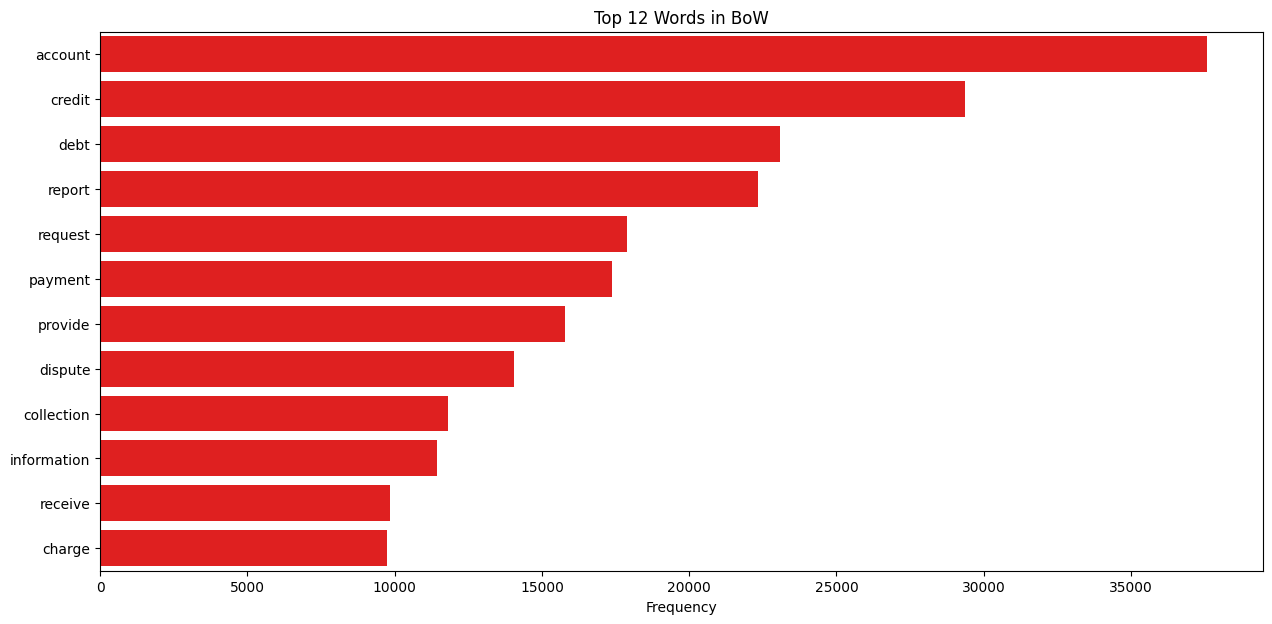

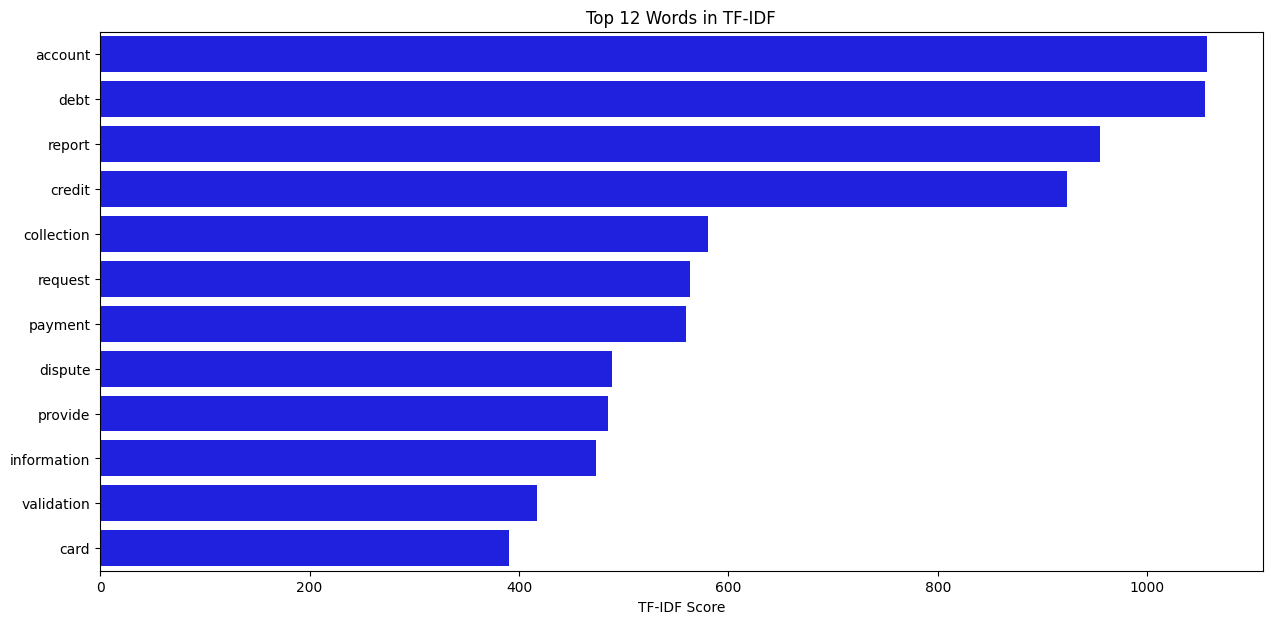

In [22]:
# From the code above, it is evident that each approach identifies different words as having the highest frequency or level of importance
# The code below creates a visual representation of the top 12 words for each approach
# Used the project example for this, provided by the lecturer

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Top Words from BoW
plt.figure(figsize=(15,7))
sns.barplot(x=BoW_df.sum().sort_values(ascending=False)[:12].values,
            y=BoW_df.sum().sort_values(ascending=False)[:12].index, color='red')
plt.title('Top 12 Words in BoW')
plt.xlabel('Frequency')
plt.ylabel('')
plt.show()

# Plot Top Words from TF-IDF
plt.figure(figsize=(15,7))
sns.barplot(x=TFIDF_df.sum().sort_values(ascending=False)[:12].values,
            y=TFIDF_df.sum().sort_values(ascending=False)[:12].index, color='blue')
plt.title('Top 12 Words in TF-IDF')
plt.xlabel('TF-IDF Score')
plt.ylabel('')
plt.show()



---



# **Most Prevalent Topics**

## **Identify the most prevalent topics using LSA**

## **Identify the most prevalent topics using LDA**

In [ ]:
# Using LDA and the BoW approach to find the most prevalent topics (corpus test)

# Import libraries and dependencies
import pandas as pd
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt # Added import for plotting

# We will use BoW_matrix as the input corpus for LDA directly.
X = BoW_matrix

# Get the vocabulary (feature names) from the CountVectorizer that created BoW_matrix.
vocabulario = vect.get_feature_names_out()

# Function to compute coherence and perplexity values for different numbers of topics
def compute_coherence_values(corpus, start, limit, step): # Removed 'vectorizer' from arguments
    coherence_values = []
    perplexity_values = []

    # Loop over the range of topics from start to limit, with the specified step
    for num_topics in range(start, limit, step):
        # Create an LDA model with the current number of topics
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(corpus)

        # Compute perplexity for the current model
        perplexity = lda_model.perplexity(corpus)
        perplexity_values.append(perplexity)

        # Compute model score as an approximation for coherence
        coherence_values.append(lda_model.score(corpus))

    # Return both coherence and perplexity values
    return coherence_values, perplexity_values

# Define the range for the number of topics
start, limit, step = 2, 10, 2

# Compute coherence and perplexity values for different numbers of topics
coherence_values, perplexity_values = compute_coherence_values(X, start, limit, step) # Called without 'vectorizer' argument

# Plotting the perplexity values
plt.plot(range(start, limit, step), perplexity_values)
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity")
plt.title("Perplexity by Number of Topics")
plt.grid(False)
plt.show()

# Define the number of topics
# Change this value to set the desired number of topics
# Selecting the model based on the coherence value
best_num_topics = np.argmin(perplexity_values) + start

# LDA Model
lda_model = LatentDirichletAllocation(n_components=best_num_topics, random_state=42)
lda_model.fit(X)

# Function to display topics with keywords
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(", ".join(top_words))
        print("\n")

# Number of words per topic
no_top_words = 5

# Display the keywords of the topics
feature_names = vocabulario # Corrected: Use vocabulario from the CountVectorizer for the full dataset
display_topics(lda_model, feature_names, no_top_words)

## **Conclusion**

text